In [187]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn

In [188]:
# some tidying of the data 

books = pd.read_csv('../../data/data_with_author_and_awards.csv')

# apply data cleaning stuff 

%run ../../data/tidy_book_tags.ipynb # to get clean_filter_tags function

%run ../../data/tidy_publisher.ipynb # to get publisher_tidy function

books['first_publisher'] = publisher_tidy(books['first_publisher'])

books['tags'] = clean_filter_tags(books['tags'])

# combine awards into one target column

books['target'] = books['hugo'] | books['locus']

/var/folders/bt/8s6v7ngs6m93f2x58bpj1zl00000gn/T/ipykernel_49695/1892821212.py:3: DtypeWarning: Columns (0: isbn) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('../../data/data_with_author_and_awards.csv')


In [189]:
# do not want books from before awards
books = books[books['release_year'] >= 1970]

In [190]:
books.head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,target
4100,689509.0,The Simultaneous Man,Ralph Blum,1970,1970-03-00,bantambooks,1932.0,"Los Angeles, California, USA",0553058789,NaN,...,False,03,38,0,0,False,False,USA,Central/North America,False
4101,2297062.0,The Three Straw Men,August Derleth,1970,1970-11-00,Other,1909.0,"Sauk City, Wisconsin, USA",0876860080,NaN,...,False,11,61,0,0,False,False,USA,Central/North America,False
4102,2499270.0,Witch's Suckling,Gimone Hall,1970,1970-09-00,Other,NaN,NaN,NaN,NaN,...,False,09,Unknown,0,0,False,False,Unknown,Unknown,False
4103,531585.0,The Sorcerer's Skull,David Mason,1970,1970-00-00,Other,1924.0,NaN,1587150638,NaN,...,False,Unknown,46,0,0,False,False,Unknown,Unknown,False
4104,1984860.0,Bantan and the Mermaids,Maurice B. Gardner,1970,1970-00-00,Other,1905.0,"Portland, Maine, USA",NaN,NaN,...,False,Unknown,65,0,0,False,False,USA,Central/North America,False


<Axes: >

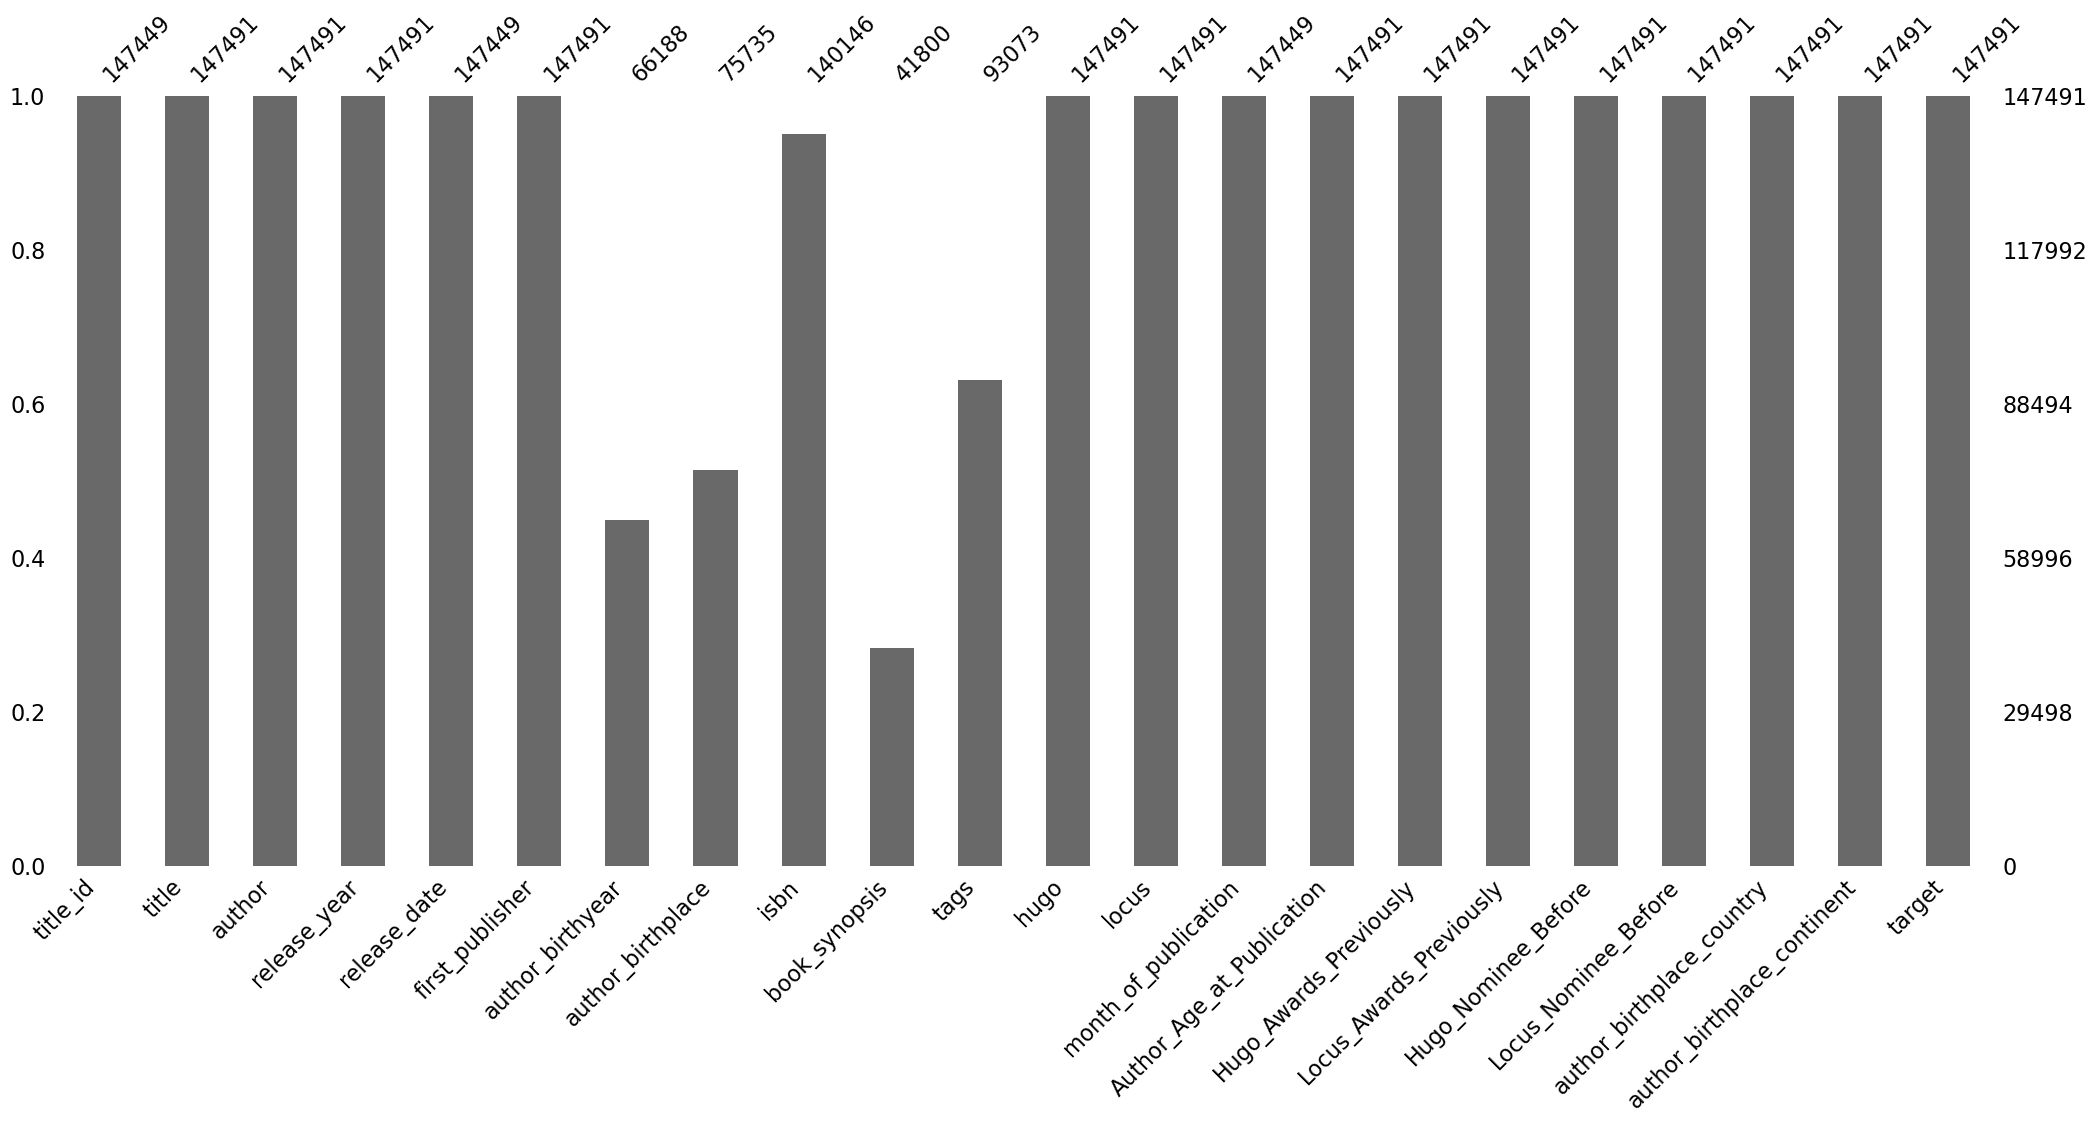

In [191]:
msno.bar(books)

In [192]:
# MISSINGNESS:
# for the sake of this notebook, we shall:
# - omit book synopses, title_id, isbn, release_date (captured in month), author_birthyear, author_birthplace (captured in country and continent)
# - and turn all empty tags into empty string ""

books = books.drop(["title_id", "isbn", "release_date", "author_birthyear", "book_synopsis", "author_birthplace"], axis=1)


In [193]:
type(books['tags'][4100])

float

In [194]:
books['tags'] = books['tags'].apply(lambda x: '' if isinstance(x, float) else x)

<Axes: >

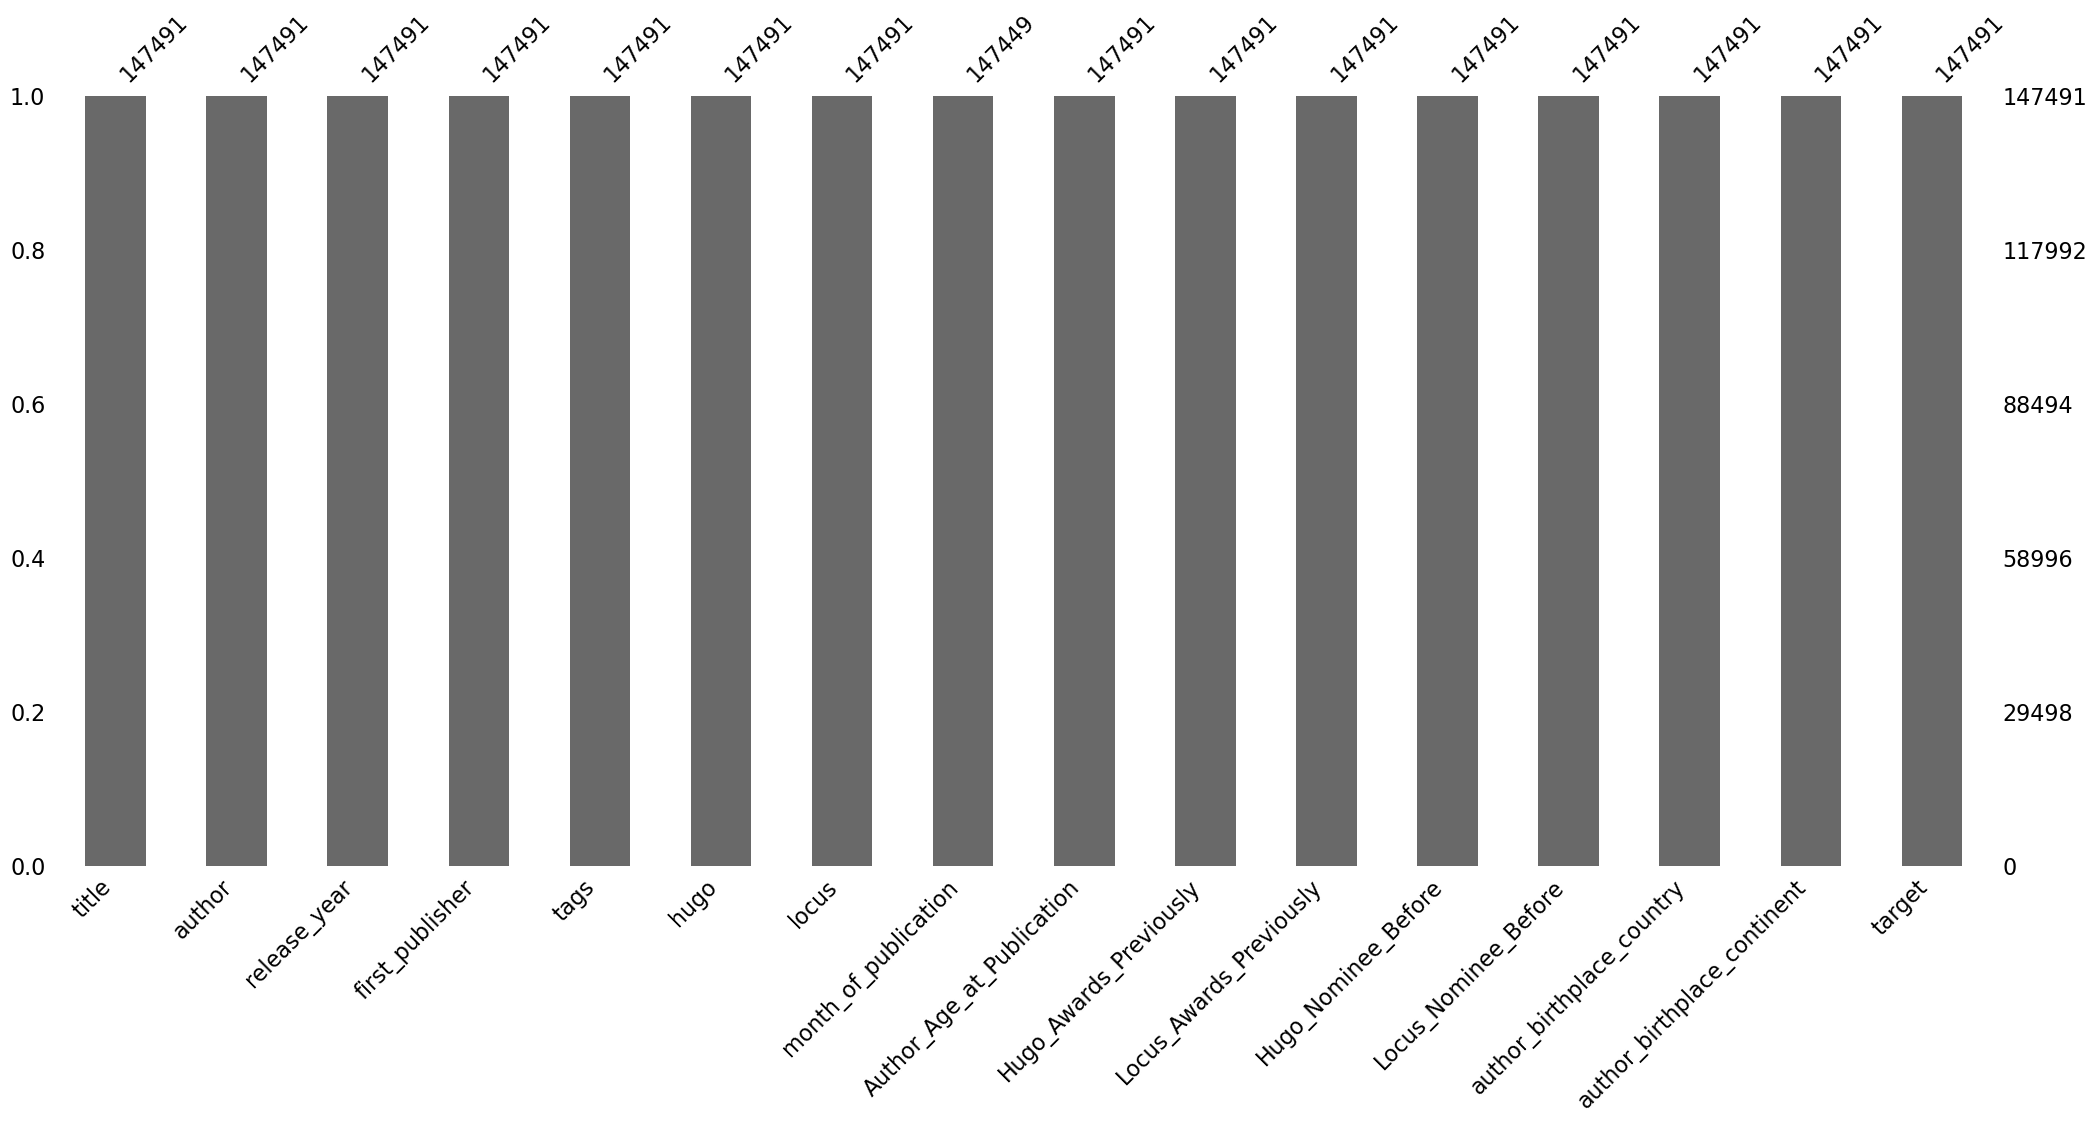

In [195]:
msno.bar(books)

In [196]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 147491 entries, 4100 to 151590
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   title                        147491 non-null  str   
 1   author                       147491 non-null  str   
 2   release_year                 147491 non-null  int64 
 3   first_publisher              147491 non-null  str   
 4   tags                         147491 non-null  object
 5   hugo                         147491 non-null  bool  
 6   locus                        147491 non-null  bool  
 7   month_of_publication         147449 non-null  str   
 8   Author_Age_at_Publication    147491 non-null  str   
 9   Hugo_Awards_Previously       147491 non-null  int64 
 10  Locus_Awards_Previously      147491 non-null  int64 
 11  Hugo_Nominee_Before          147491 non-null  bool  
 12  Locus_Nominee_Before         147491 non-null  bool  
 13  author_birthplace_coun

In [197]:
books['Author_Age_at_Publication'] = pd.to_numeric(
    books['Author_Age_at_Publication'], errors='coerce'
)


In [198]:
books_tt = books[(books['release_year'] >= 1970) & (books['release_year'] < 2010)]
books_val = books[(books['release_year'] >= 2010) & (books['release_year'] < 2015)]

books_test = books[(books['release_year'] >= 2015)]


In [199]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 147491 entries, 4100 to 151590
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   title                        147491 non-null  str    
 1   author                       147491 non-null  str    
 2   release_year                 147491 non-null  int64  
 3   first_publisher              147491 non-null  str    
 4   tags                         147491 non-null  object 
 5   hugo                         147491 non-null  bool   
 6   locus                        147491 non-null  bool   
 7   month_of_publication         147449 non-null  str    
 8   Author_Age_at_Publication    66188 non-null   float64
 9   Hugo_Awards_Previously       147491 non-null  int64  
 10  Locus_Awards_Previously      147491 non-null  int64  
 11  Hugo_Nominee_Before          147491 non-null  bool   
 12  Locus_Nominee_Before         147491 non-null  bool   
 13  author_

##### Preprocessing of columns

In [200]:
#  0   title                        147491 non-null  str   -- not used
#  1   author                       147491 non-null  str   -- not used
#  2   release_year                 147491 non-null  int64 -- used (for normalization per yar)
#  3   first_publisher              147491 non-null  str   -- use (catergorical)
#  4   tags                         147491 non-null  object -- use (multilabel binarize)
#  5   hugo                         147491 non-null  bool  -- not used (use combine target)
#  6   locus                        147491 non-null  bool  -- not used (use combine target)
#  7   month_of_publication         147449 non-null  str   -- use (categorical)
#  8   Author_Age_at_Publication    147491 non-null  int64   -- use (numerical)
#  9   Hugo_Awards_Previously       147491 non-null  int64 -- use (numerical)
#  10  Locus_Awards_Previously      147491 non-null  int64 -- use (numerical)
#  11  Hugo_Nominee_Before          147491 non-null  bool  -- use (numerical)
#  12  Locus_Nominee_Before         147491 non-null  bool  -- use (numerical)
#  13  author_birthplace_country    147491 non-null  str   -- use (categorical) 
#  14  author_birthplace_continent  147491 non-null  str   -- use (categorical)
#  15  target                       147491 non-null  bool  -- target (categorical or numerical)

In [201]:
numerical_features = ["Hugo_Awards_Previously", "Locus_Awards_Previously"]
categorical_features = ["first_publisher", "month_of_publication", "author_birthplace_country", "author_birthplace_continent"]
mlb_features = ["tags"]
bool_features = ["Hugo_Nominee_Before", "Locus_Nominee_Before"]

In [202]:
for col in numerical_features:
    books_tt[col] = books_tt[col].astype(float)

In [203]:
## do multilabel binarizer of tags outside preprocessing. 
from sklearn.preprocessing import MultiLabelBinarizer

tag_labeler = MultiLabelBinarizer()
tag_labels = tag_labeler.fit_transform(books_tt['tags'].fillna(''))

# save as dataframe
tag_dataframe = pd.DataFrame(
    tag_labels,
    columns = ["tag_{}".format(tag) for tag in tag_labeler.classes_],
    index=books_tt.index
)

# concatenate to training dataframe
books_tt = pd.concat([books_tt, tag_dataframe], axis=1)

In [204]:
# calculate dot product with other books' genre tags
from sklearn.metrics.pairwise import cosine_similarity

def get_similarity_list(df):
    for year, data in df.groupby('release_year'):
        tag_data = data[list(tag_dataframe.columns)]
        similarity = cosine_similarity(tag_data)
        np.fill_diagonal(similarity, np.nan)
        book_mean_similarity = np.nanmean(similarity, axis=0)
    return book_mean_similarity

In [205]:
books_tt.info()

<class 'pandas.DataFrame'>
RangeIndex: 47984 entries, 4100 to 52083
Columns: 132 entries, title to tag_zombi
dtypes: bool(5), float64(3), int64(117), object(1), str(6)
memory usage: 49.5+ MB


for some features, we want to normalize against the rest of the cohort.

for numerical features, this is z-score normalization, through StandardScaler().

but, we want to normalize within each year, not across all years.

let's try to build a custom transformer with guidance from https://www.andrewvillazon.com/custom-scikit-learn-transformers/


In [215]:
from numpy.random import randint
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

class YearByYearStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, year_column='year', scale_columns=None):
        self.scale_columns = scale_columns
        self.year_column = year_column

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        # apply standard scaler to each year group by group
        for year, data in X.groupby(by=self.year_column):
            imputer = SimpleImputer(strategy='mean')
            X.loc[data.index, self.scale_columns] = imputer.fit_transform(data[self.scale_columns])

            scaler = StandardScaler()
            # print(X.loc[data.index, 'Locus_Awards_Previously'].mean(), X.loc[data.index, 'Locus_Awards_Previously'].std())
            X.loc[data.index, self.scale_columns] = scaler.fit_transform(data[self.scale_columns])#pd.DataFrame(scaler.fit_transform(data[self.scale_columns]))
            # print(X.loc[data.index, self.scale_columns])
        return X.drop(columns=[self.year_column])
    
    def get_feature_names_out(self, input_features=None):
            """Returns feature names for the output data."""
            # 1. Fall back to features seen during fit if input_features isn't explicitly passed
            if input_features is None:
                if hasattr(self, "feature_names_in_"):
                    input_features = self.feature_names_in_
                else:
                    raise ValueError("Transformer must be fitted or input_features must be passed.")
            
            # 2. Convert to numpy array to allow array-based boolean filtering
            input_features = np.asarray(input_features, dtype=object)
            
            # 3. Filter out the year column, keeping everything else in exact order
            return input_features[input_features != self.year_column]

class YearlyGenreTagScaler(BaseEstimator, TransformerMixin):
    def __init__(self, year_column='year', tag_columns=None):
        self.tag_columns = tag_columns
        self.year_column = year_column

    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X, y=None):
        X = X.copy()

        similarity_series = pd.Series(dtype=float, index=X.index)

        for year, data in X.groupby(by=self.year_column):
            tag_data = data[self.tag_columns]
            similarity = cosine_similarity(tag_data)
            book_mean_similarity = np.mean(similarity, axis=0)
            similarity_series.loc[data.index] = book_mean_similarity

        X['cohort_similiarity'] = similarity_series
        return X.drop(columns=self.tag_columns+ [self.year_column])
    
def get_feature_names_out(self, input_features=None):
        """Returns feature names for the output data."""
        # 1. Fall back to features seen during fit if input_features isn't explicitly passed
        if input_features is None:
            if hasattr(self, "feature_names_in_"):
                input_features = self.feature_names_in_
            else:
                raise ValueError("Transformer must be fitted or input_features must be passed.")
        
        # 2. Convert to numpy array to allow array-based boolean filtering
        input_features = np.asarray(input_features, dtype=object)
        
        # 3. Filter out the year column, keeping everything else in exact order
        return input_features[input_features != self.year_column]

In [216]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

tags_pipeline = Pipeline(
    steps=[
        ('similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'))
    ]
)

feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('onehot', categorical_pipeline, categorical_features),
        ('tag_similarity', tags_pipeline, list(tag_dataframe.columns) + ['release_year'])
    ],
    remainder='passthrough'
)

In [217]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn import svm
from sklearn.base import clone
import xgboost as xgb

models = {
    'dummy_mostfrequent': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('modelling', DummyClassifier(strategy='most_frequent'))
    ]
    ),
    'dummy_stratified': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('modelling', DummyClassifier(strategy='stratified'))
    ]
    ),
    'simple_classifier': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('logistic', LogisticRegression(max_iter=1000))
    ]
    ),
    'simple_classifier_balanced': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('logistic', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]
    ),
        'svc': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('svc', svm.SVC())
    ]
    ),

            'decision_tree': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('tree', tree.DecisionTreeClassifier())
    ]
    ),
    # xgb boost ranker with default hyperparams
            'xgb_rank': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('xgb_rank', xgb.XGBRanker(tree_method="hist", lambdarank_num_pair_per_sample=8, objective="rank:ndcg", lambdarank_pair_method="topk"))
    ]
    ),
}

In [218]:
## implementing different time series splitting

# Sliding Window (Rolling Cross-Validation): train on past few years

def sliding_window_split(data, train_window_size=10, val_size=1):
    # data is a data
    years = data['release_year'].unique()
    num_years = len(years)

    window_splits = []

    for i in range(num_years - train_window_size - val_size + 1):
        window_start = i
        window_end = i + train_window_size
        val_start = window_end
        val_end = val_start + val_size

        window = data[data['release_year'].isin(years[window_start:window_end])]
        val = data[data['release_year'].isin(years[val_start:val_end])]

        window_splits.append((window, val))

    return window_splits




In [219]:
books_val = books[(books['release_year'] >= 2010) & (books['release_year'] < 2015)]

tags_binarized = tag_labeler.transform(books_val['tags'].fillna(''))
tags_df = pd.DataFrame(
tags_binarized, 
columns=[f"tag_{c}" for c in tag_labeler.classes_],
index=books_val.index
)
books_val = pd.concat([books_val, tags_df], axis=1)

for col in numerical_features:
    books_val[col] = books_tt[col].astype(float)

additional_scores = {}
preds = {}

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['standalon', 'supervillain'] will be ignored
  warnings.warn(


=== dummy_mostfrequent ===
Mean f1-score: 0.0; Max: 0.0; Min: 0.0
=== dummy_stratified ===
Mean f1-score: 0.041263681739775696; Max: 0.07547169811320754; Min: 0.0
=== simple_classifier ===
Mean f1-score: 0.2257840158784146; Max: 0.3793103448275862; Min: 0.1016949152542373
=== simple_classifier_balanced ===
Mean f1-score: 0.2363086037059961; Max: 0.321285140562249; Min: 0.16042780748663102
=== svc ===
Mean f1-score: 0.2569843966647021; Max: 0.39215686274509803; Min: 0.09523809523809523
=== decision_tree ===
Mean f1-score: 0.29644955939145856; Max: 0.411214953271028; Min: 0.16260162601626016
=== xgb_rank ===
Mean f1-score: 0.42798689276010393; Max: 0.5869565217391305; Min: 0.3111111111111111


Text(0.5, 1.0, 'nested time CV, sliding window (rolling cross-validation) of 15 years')

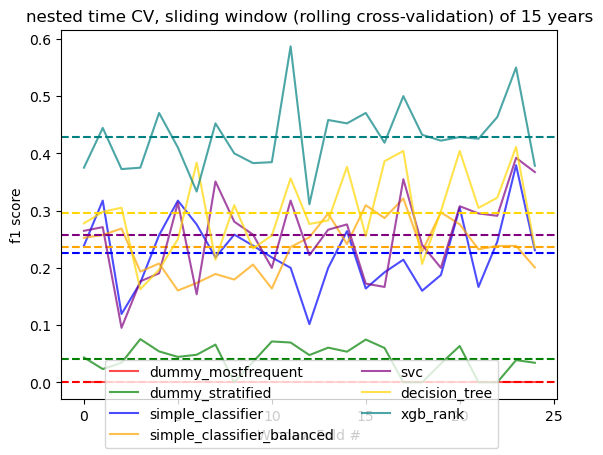

In [220]:
windows = sliding_window_split(books_tt, train_window_size=15)

colors = ['red', 'green', 'blue', 'orange', 'purple', 'gold', 'teal']

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year']

i = 0

fig = plt.figure()

confusion_matrices = {}

for name, model in models.items():
    print("=== {} ===".format(name))

    mean_score = 0
    scores = []

    for num, fold in enumerate(windows):
        book_train = fold[0]
        book_val = fold[1]


        if name == 'xgb_rank':

            model.fit(book_train[features], book_train['target'], xgb_rank__qid=book_train['release_year'])

            num_finalists = int(book_val['target'].sum())

            ypred = model.predict(book_val[features])

            # pick the top books to be finalists: check against number of finalists in the dataset 
            book_data_copy = book_val
            book_data_copy['predicted'] = ypred
            finalists = book_data_copy.groupby('release_year')['predicted'].nlargest(num_finalists).index.droplevel(0)

            book_val['predicted'] = 0
            book_val.loc[finalists, 'predicted'] = 1

            ypred = book_val['predicted']

        else:
            model.fit(book_train[features], book_train['target'])

            ypred = model.predict(book_val[features])


        score = f1_score(book_val['target'], ypred)

        scores.append(score)

        tn, fp, fn, tp = confusion_matrix(book_val['target'], ypred).ravel().tolist()

        conf = confusion_matrix(book_val['target'], ypred, normalize='true')#.ravel().tolist()
        confs += conf / len(windows)

        # print(" Fold {}: f1-score of {}, tp: {}, fn: {}".format(num + 1, score, tp, fn))

        mean_score += score / len(windows)

    confusion_matrices[name] = confs

    print("Mean f1-score: {}; Max: {}; Min: {}".format(mean_score, max(scores), min(scores)))

    plt.plot(list(range(len(windows))), scores, label = name, alpha = 0.7, color=colors[i])
    plt.axhline(mean_score, color=colors[i], linestyle='dashed')
    i += 1

plt.xlabel("Window Fold #")
plt.ylabel("f1 score")

fig.legend(loc="lower center", ncol = 2)
plt.title("nested time CV, sliding window (rolling cross-validation) of 15 years")


In [221]:
# Walk-Forward Validation: re-train on increasingly larger training set

def walk_forward(data, initial_size=5, step=1):
    # data is a data
    years = data['release_year'].unique()
    num_years = len(years)
    splits = []

    for i in range(initial_size, num_years - initial_size - step + 1):
        # print(num_years - initial_size - step + 1)
        data_start = 0
        data_end = i
        val_start = data_end
        val_end = val_start + step
        print()

        window = data[data['release_year'].isin(years[data_start:data_end])]
        val = data[data['release_year'].isin(years[val_start:val_end])]

        splits.append((window, val))

    return splits

windows = walk_forward(books_tt)


=== dummy_mostfrequent ===
Mean f1-score: 0.0; Max: 0.0; Min: 0.0
=== dummy_stratified ===
Mean f1-score: 0.04069085144534901; Max: 0.1111111111111111; Min: 0.0
=== simple_classifier ===
Mean f1-score: 0.253803973663557; Max: 0.42105263157894735; Min: 0.10344827586206896
=== simple_classifier_balanced ===
Mean f1-score: 0.25227664515352083; Max: 0.3902439024390244; Min: 0.13921113689095127
=== svc ===
Mean f1-score: 0.3030269371264053; Max: 0.4419889502762431; Min: 0.2112676056338028
=== svc_yearweighted ===


KeyboardInterrupt: 

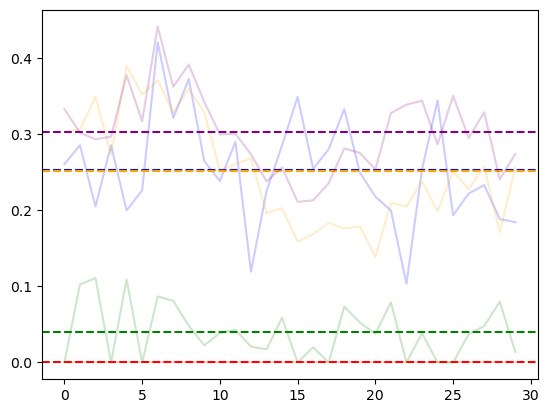

In [ ]:
models_2 = {
    
    'dummy_mostfrequent': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('modelling', DummyClassifier(strategy='most_frequent'))
    ]
    ),
    'dummy_stratified': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('modelling', DummyClassifier(strategy='stratified'))
    ]
    ),
    'simple_classifier': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('logistic', LogisticRegression(max_iter=1000))
    ]
    ),
    'simple_classifier_balanced': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('logistic', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]
    ),
        'svc': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('svc', svm.SVC(kernel='rbf', class_weight='balanced'))
    ]
        ),
        'svc_yearweighted': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('svc_yearweighted', svm.SVC(kernel='rbf', class_weight='balanced'))
    ]
    ),

            'decision-tree': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('tree', tree.DecisionTreeClassifier())
    ]
    ),
    # xgb boost ranker with default hyperparams
            'xgb_rank': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('xgb_rank', xgb.XGBRanker(tree_method="hist", lambdarank_num_pair_per_sample=8, objective="rank:ndcg", lambdarank_pair_method="topk"))
    ]
    ),

    

}

colors = ['red', 'green', 'blue', 'orange', 'purple', 'gold', 'teal', 'black']

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year']

i = 0

fig = plt.figure()

confusion_matrices = {}

for name, model in models_2.items():
    print("=== {} ===".format(name))

    mean_score = 0
    scores = []
    confs = np.zeros((2,2))

    for num, fold in enumerate(windows):
        book_train = fold[0]
        book_val = fold[1]



        if name == 'svc_yearweighted': # weight the older years less

            model.fit(book_train[features], book_train['target'],
                    svc_yearweighted__sample_weight=np.exp(-0.5*(max(book_train['release_year']) - book_train['release_year'])))

            ypred = model.predict(book_val[features])

        elif name == 'xgb_rank':

            model.fit(book_train[features], book_train['target'], xgb_rank__qid=book_train['release_year'])

            num_finalists = int(book_val['target'].sum())

            ypred = model.predict(book_val[features])

            # pick the top books to be finalists: check against number of finalists in the dataset 
            book_data_copy = book_val
            book_data_copy['predicted'] = ypred
            finalists = book_data_copy.groupby('release_year')['predicted'].nlargest(num_finalists).index.droplevel(0)

            book_val['predicted'] = 0
            book_val.loc[finalists, 'predicted'] = 1

            ypred = book_val['predicted']

        else:
            model.fit(book_train[features], book_train['target'])

            ypred = model.predict(book_val[features])

        score = f1_score(book_val['target'], ypred)

        scores.append(score)

        conf = confusion_matrix(book_val['target'], ypred, normalize='true')#.ravel().tolist()
        confs += conf / len(windows)

        # print(" Fold {}: f1-score of {}, tp: {}, fn: {}".format(num + 1, score, tp, fn))

        mean_score += score / len(windows)

    print("Mean f1-score: {}; Max: {}; Min: {}".format(mean_score, max(scores), min(scores)))

    confusion_matrices[name] = confs

    plt.plot(list(range(len(windows))), scores, label = name, alpha = 0.2, color=colors[i])
    plt.axhline(mean_score, color=colors[i], linestyle='dashed')
    i += 1

plt.xlabel("Fold #")
plt.ylabel("f1 score")

fig.legend(loc="lower center", ncol = 2)
plt.title("nested time CV, Walk-Forward Validation with step of 1")


let's plot some other plots: for example, precision recall curves for all of these, and confusion matrix curves.

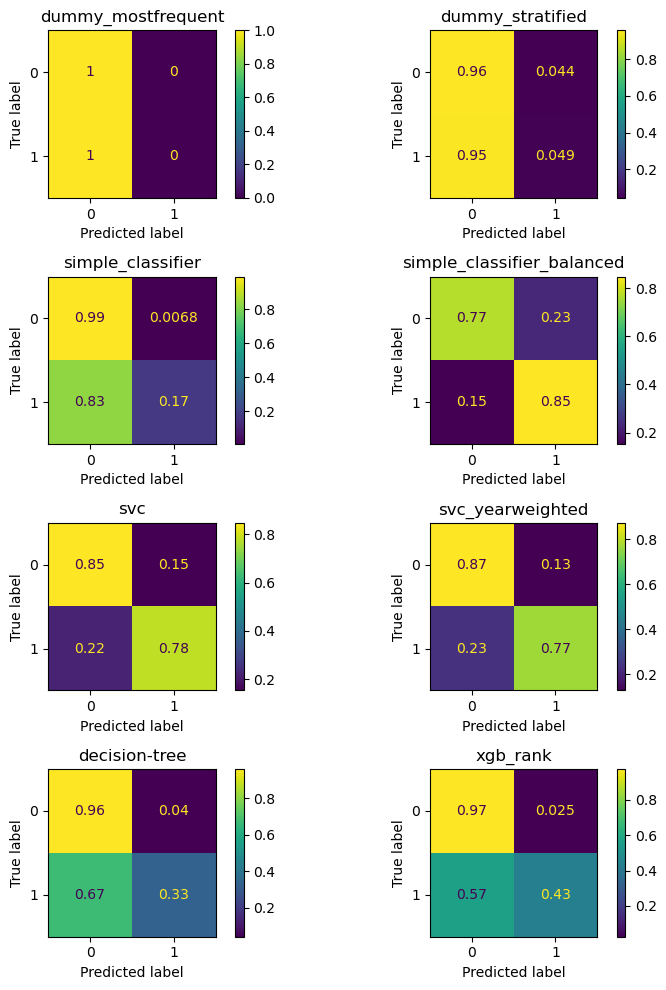

In [214]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8,10))

for model, ax in zip(models_2.keys(), axes.flatten()):
    conf = confusion_matrices[model]
    ConfusionMatrixDisplay(confusion_matrix=conf).plot(ax=ax)

    ax.set_title(model)
plt.tight_layout()  
plt.show()

notes:
- the models' f1 scores vary a lot across different folds, not great. how can this be improved?
- xgb_rank has the most promising balance between true negatives and percent of true positives identified, worth looking into that and trying to improve it
- svc_yearweighted also looks possibly promising?
